# 04 — ML Model Development: Part 1 (Price & Value Retention Analysis)

This notebook develops machine learning models for predicting Steam game pricing outcomes.

The goal is to model two related problems:

- **[Regression]** Predict `current_price` — the current price of a game in PHP.
- **[Classification]** Predict `value_retention_tier` — whether a game keeps its launch value or becomes heavily discounted over time.

Data source: `cleaned_games` table from the cleaned Steam database, which combines Steam Storefront, SteamSpy, review, pricing, and player engagement features into one analysis-ready dataset.

ML problems:

- **[Regression]** Predict `current_price` using game age, launch price, reviews, ownership, achievements, genre, developer tier, multiplayer status, and price tier.
- **[Classification]** Predict `value_retention_tier` based on the ratio between `current_price` and `initial_price`.

Steps:

1. Load and inspect the data
2. Define targets (Step 4.1)
3. Select features and preprocess data (Step 4.3)
4. Train/test split (Step 4.2)
5. Regression models for current price prediction (Step 4.4)
6. Classification models for value retention tier prediction (Step 4.5)
7. Model comparison and feature importance

## Setup

In [ ]:
import subprocess
import sys
import warnings
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "cleaned data" / "steam (1)_cleaned 1.db"

# Guard: stop early if DB path is wrong
assert DB_PATH.exists(), f"DB not found at: {DB_PATH}"

# Connect to database
conn = sqlite3.connect(DB_PATH)

print(f"Connected to: {DB_PATH}")
print("Tables:", [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()])

Connected to: /Users/faithtiukinhoy/Documents/GitHub/Y2T2-Final-Project/cleaned data/steam (1)_cleaned 1.db
Tables: ['app_list', 'games', 'game_genres', 'game_categories', 'reviews_summary', 'review_timestamps', 'steamspy', 'steamspy_tags', 'itad_mapping', 'price_history', 'player_counts', 'steamcharts_history', 'cleaned_games']


> ## Step 4.1: Define Target Variables

In this step, we define the targets for both regression and classification tasks.

### Regression Target
- **current_price (PHP)** — predicts the absolute current price of a game.

### Classification Target
We construct a new variable called **value_retention_tier**, which measures how well a game retains its value over time. This is based on the ratio:

value_ratio = current_price / initial_price

The tiers are defined as:
- **Premium Hold** (> 0.85) — retains most of its value, rarely discounted
- **Standard Depreciation** (0.50 – 0.85)
- **Heavy Discount** (0.25 – 0.50)
- **Permanent Bargain** (< 0.25)

We then examine the class distribution to check for imbalance, which may require techniques such as class weighting or SMOTE in later steps.

Regression Target: current_price

Class Distribution:
value_retention_tier
Standard Depreciation    2646
Premium Hold              430
Permanent Bargain         415
Heavy Discount            329
Name: count, dtype: int64


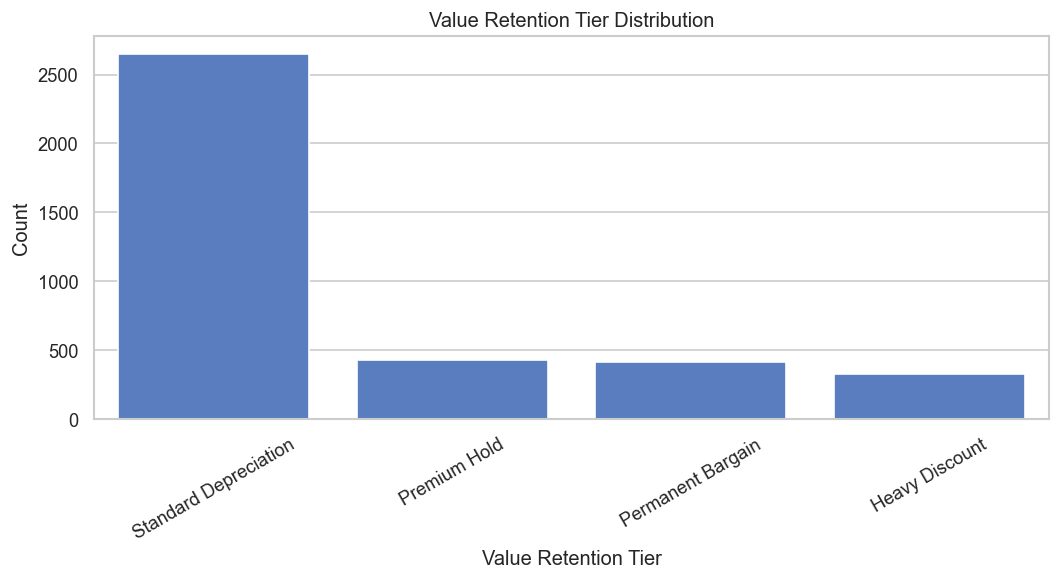

In [14]:
# Make a modeling copy
df_model = df.copy()

# Remove invalid initial prices to avoid division errors
df_model = df_model[df_model['initial_price'] > 0].copy()

# Regression target
regression_target = 'current_price'

# Create value retention ratio
df_model['value_ratio'] = df_model['current_price'] / df_model['initial_price']

# Classification target with the 1+ year Premium Hold condition
def categorize_value(row):
    ratio = row['value_ratio']
    age = row['days_since_release']
    discounted = row['ever_discounted']  # IMPORTANT
    
    # True premium = old + high price + rarely discounted
    if ratio > 0.85 and age >= 365 and discounted == 0:
        return "Premium Hold"
    
    elif ratio > 0.50:
        return "Standard Depreciation"
    
    elif ratio > 0.25:
        return "Heavy Discount"
    
    else:
        return "Permanent Bargain"

df_model['value_retention_tier'] = df_model.apply(categorize_value, axis=1)

# Check class distribution
class_counts = df_model['value_retention_tier'].value_counts()

print("Regression Target:", regression_target)
print("\nClass Distribution:")
print(class_counts)

# Visualize class distribution
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_model,
    x='value_retention_tier',
    order=class_counts.index
)

plt.title("Value Retention Tier Distribution")
plt.xlabel("Value Retention Tier")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Summary of Target Variable Construction

The regression target, **current_price**, was directly used to predict the absolute market price of each game.

For the classification task, a new variable **value_retention_tier** was created based on the ratio of current price to initial price. This allows us to categorize games according to how well they retain value over time.

A key refinement was incorporating both **time (days_since_release ≥ 365)** and **discount behavior (ever_discounted)** when defining the **Premium Hold** category. This ensures that only older games that have maintained high prices without frequent discounts are classified as true premium retainers.

The resulting class distribution shows that:
- The majority of games fall under **Standard Depreciation**, which is expected as most games gradually decrease in price.
- A smaller portion are classified as **Premium Hold**, indicating strong value retention.
- The remaining classes (**Heavy Discount** and **Permanent Bargain**) represent games that experience significant price drops.

Although there is some class imbalance, it reflects realistic market behavior. This will be addressed in later modeling steps using techniques such as class weighting to ensure balanced learning across categories.

> ## Step 4.2: Train/Test Split

We split the dataset separately for the regression and classification tasks.

For the **regression model**, a standard 80/20 random split is used because `current_price` is a continuous target.

For the **classification model**, an 80/20 stratified split is used based on `value_retention_tier`. This keeps the same class proportions in both the training and testing sets, which is important because the class distribution is imbalanced.

A temporal validation option is also checked by separating older games from newer releases. This provides an alternative way to test whether the model can generalize to newer Steam titles.

Regression Split
Train shape: (3056, 90)
Test shape: (764, 90)

Classification Split
Train shape: (3056, 90)
Test shape: (764, 90)


,Train Proportion,Test Proportion
value_retention_tier,,
Heavy Discount,0.086060,0.086387
Permanent Bargain,0.108639,0.108639
Premium Hold,0.112565,0.112565
Standard Depreciation,0.692736,0.692408


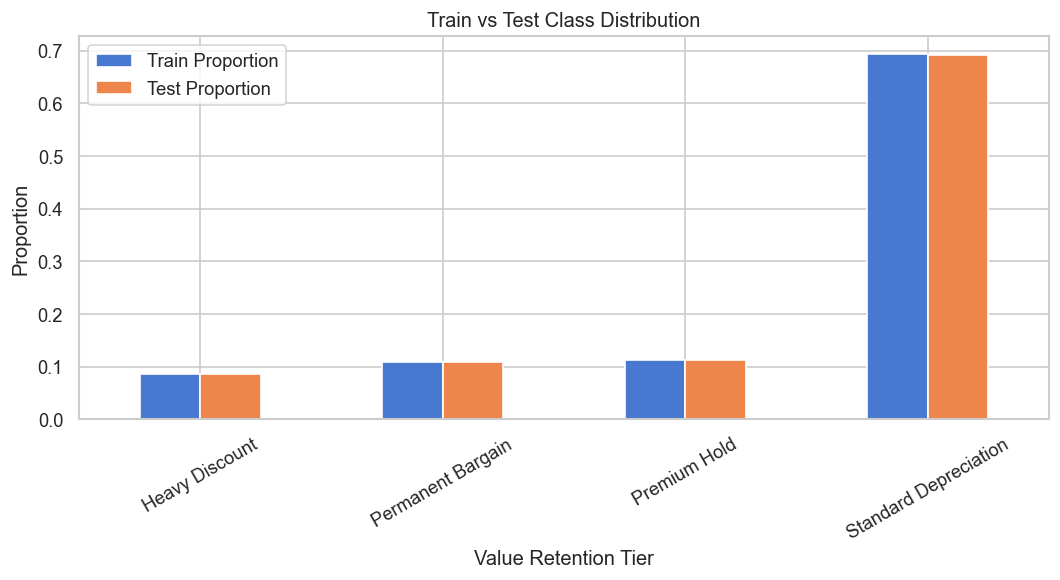

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.copy()

# Targets
y_reg = df_model['current_price']
y_cls = df_model['value_retention_tier']

# Regression: simple 80/20 random split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification: 80/20 stratified split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Regression Split")
print("Train shape:", X_train_reg.shape)
print("Test shape:", X_test_reg.shape)

print("\nClassification Split")
print("Train shape:", X_train_cls.shape)
print("Test shape:", X_test_cls.shape)

# Compare class proportions
train_dist = y_train_cls.value_counts(normalize=True).sort_index()
test_dist = y_test_cls.value_counts(normalize=True).sort_index()

split_dist = pd.DataFrame({
    "Train Proportion": train_dist,
    "Test Proportion": test_dist
})

display(split_dist)

# Plot train vs test class distribution
split_dist.plot(kind="bar", figsize=(9, 5))

plt.title("Train vs Test Class Distribution")
plt.ylabel("Proportion")
plt.xlabel("Value Retention Tier")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### Discussion

The regression dataset was split using a standard 80/20 random split because the target variable, `current_price`, is continuous. For the classification task, stratification was applied using `value_retention_tier` so that the train and test sets preserve the same class proportions.

The train-versus-test distribution plot confirms that the class balance is maintained after splitting. This is important because the target is imbalanced, with Standard Depreciation being the dominant class. Maintaining proportional representation helps make the evaluation more reliable.

The temporal split was also checked as an alternative validation strategy. This setup is useful because it tests whether models trained on older game releases can generalize to newer games released from 2023 onward.

> ## Step 4.3: Feature Selection and Preprocessing

In this step, we define the input features used for both regression and classification models.

### Selected Features

**Numerical Features:**
- days_since_release  
- initial_price  
- review_score  
- log_ownership  
- total_reviews  
- achievements_total  

**Categorical Features:**
- primary_genre  
- developer_tier  
- is_multiplayer  
- price_tier  

These features were selected because they capture key aspects of a game's lifecycle, pricing strategy, popularity, and structural attributes.

### Excluded Features

The following features were excluded to prevent data leakage or redundancy:
- `current_price` (excluded from classification to avoid target leakage)
- `current_discount_depth` (direct proxy for price changes)
- `appid`, `title`, `developer`, `publisher` (high-cardinality identifiers)

### Preprocessing Steps

- **Categorical variables** are transformed using one-hot encoding.
- **Numerical variables** are scaled using StandardScaler.
- A unified preprocessing pipeline is constructed to ensure consistent transformations across all models.

In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Feature selection
num_features = [
    'days_since_release',
    'initial_price',
    'review_score',
    'log_ownership',
    'total_reviews',
    'achievements_total'
]

cat_features = [
    'primary_genre',
    'developer_tier',
    'is_multiplayer',
    'price_tier'
]


# Clean dataset (remove missing values)
df_model_clean = df_model.dropna(subset=num_features + cat_features + ['current_price']).copy()


# Define X and y
X = df_model_clean[num_features + cat_features]

y_reg = df_model_clean['current_price']
y_cls = df_model_clean['value_retention_tier']

print("Final feature set shape:", X.shape)


# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# Check transformed feature size
X_transformed = preprocessor.fit_transform(X)

print("Transformed feature shape:", X_transformed.shape)

Final feature set shape: (3820, 10)
Transformed feature shape: (3820, 36)


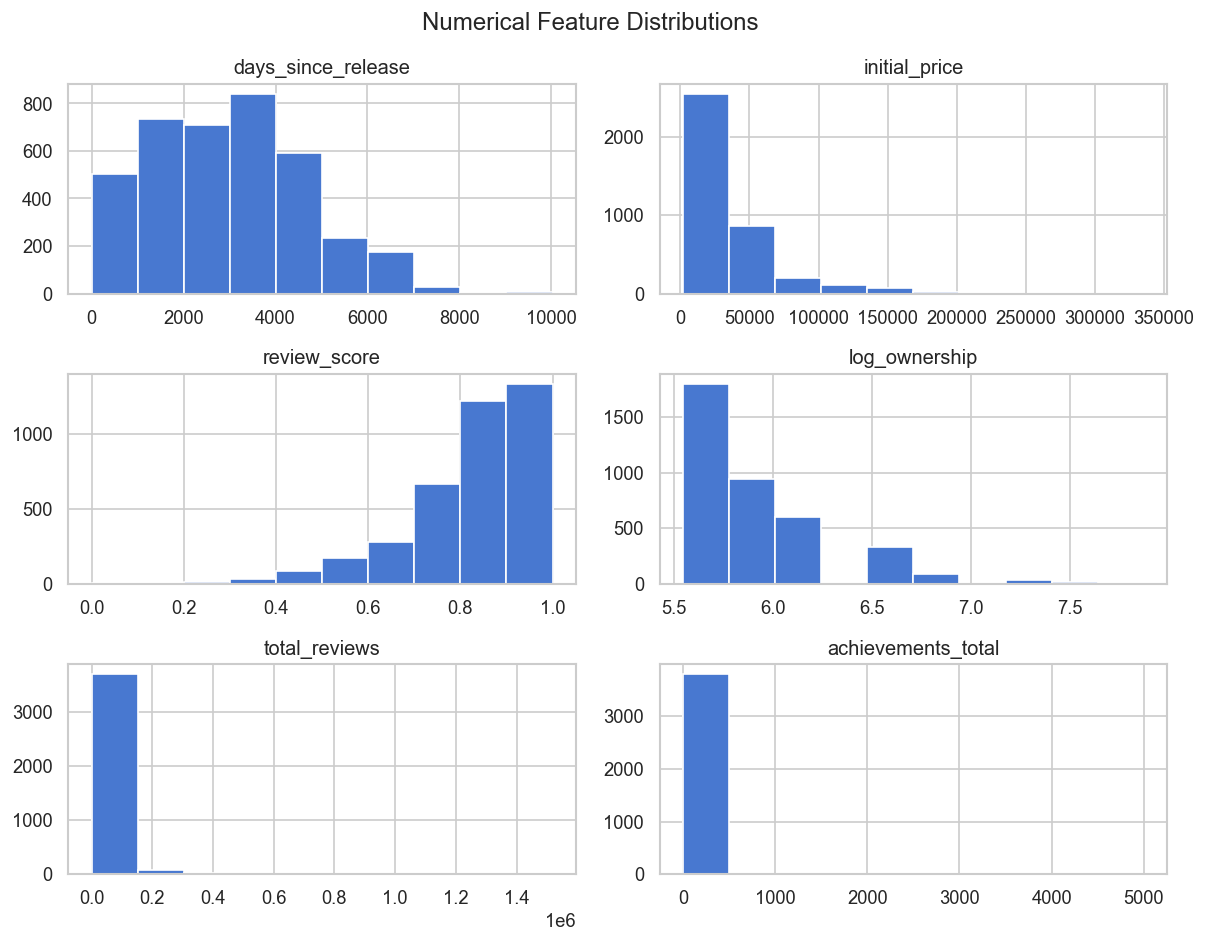

In [ ]:
# Visualize distribution of numerical features 
df_model_clean[num_features].hist(figsize=(10, 8))
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

### Discussion

The selected features include both numerical and categorical variables that capture pricing behavior, game popularity, and structural characteristics. These features are expected to influence both current price levels and value retention patterns.

High-cardinality identifiers such as appid, title, developer, and publisher were excluded because they do not generalize well and may introduce noise into the model.

To ensure proper model training, preprocessing was applied:
- Numerical features were scaled to standardize their ranges.
- Categorical features were one-hot encoded to allow models to interpret them numerically.

The transformed feature space is larger due to one-hot encoding, which expands categorical variables into multiple binary indicators. This is expected and necessary for most machine learning models.

Overall, this preprocessing pipeline ensures consistency and prevents data leakage, making it suitable for both regression and classification tasks.

> ## Step 4.4: Regression Model — Predict Current Price

In this step, regression models are trained to predict the **current_price** of each Steam game in PHP.

The baseline model is **Linear Regression**, which provides a simple benchmark. After that, three advanced models are tested:

- **Ridge Regression**
- **Random Forest Regressor**
- **Gradient Boosting Regressor**

The models are evaluated using:

- **MAE** — average absolute prediction error
- **RMSE** — penalizes larger prediction errors
- **R²** — explains how much variance in current price is captured by the model

The best model is selected based on the lowest RMSE.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Features for regression
X_train_reg_final = X_train_reg[num_features + cat_features]
X_test_reg_final = X_test_reg[num_features + cat_features]

# Helper function for model evaluation
def evaluate_regression_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

regression_results = []

# Baseline: Linear Regression
lin_model = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

lin_model.fit(X_train_reg_final, y_train_reg)
y_pred_lin = lin_model.predict(X_test_reg_final)

regression_results.append(
    evaluate_regression_model("Linear Regression", y_test_reg, y_pred_lin)
)

# Advanced Model 1: Ridge Regression
ridge_model = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train_reg_final, y_train_reg)
y_pred_ridge = ridge_model.predict(X_test_reg_final)

regression_results.append(
    evaluate_regression_model("Ridge Regression", y_test_reg, y_pred_ridge)
)

# Advanced Model 2: Random Forest Regressor
rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

rf_model.fit(X_train_reg_final, y_train_reg)
y_pred_rf = rf_model.predict(X_test_reg_final)

regression_results.append(
    evaluate_regression_model("Random Forest", y_test_reg, y_pred_rf)
)

# Advanced Model 3: Gradient Boosting Regressor
gb_model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train_reg_final, y_train_reg)
y_pred_gb = gb_model.predict(X_test_reg_final)

regression_results.append(
    evaluate_regression_model("Gradient Boosting", y_test_reg, y_pred_gb)
)

# Display model comparison table
regression_results_df = pd.DataFrame(regression_results).sort_values("RMSE")
display(regression_results_df)

,Model,MAE,RMSE,R²
3,Gradient Boosting,8432.711909,13945.770367,0.759069
2,Random Forest,8150.022194,14262.935574,0.747985
1,Ridge Regression,9369.751844,15298.866029,0.710048
0,Linear Regression,9389.510535,15303.396779,0.709876


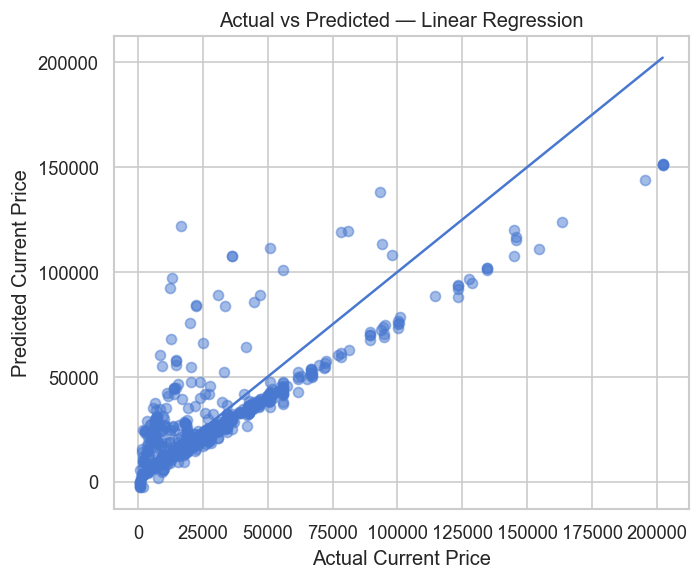

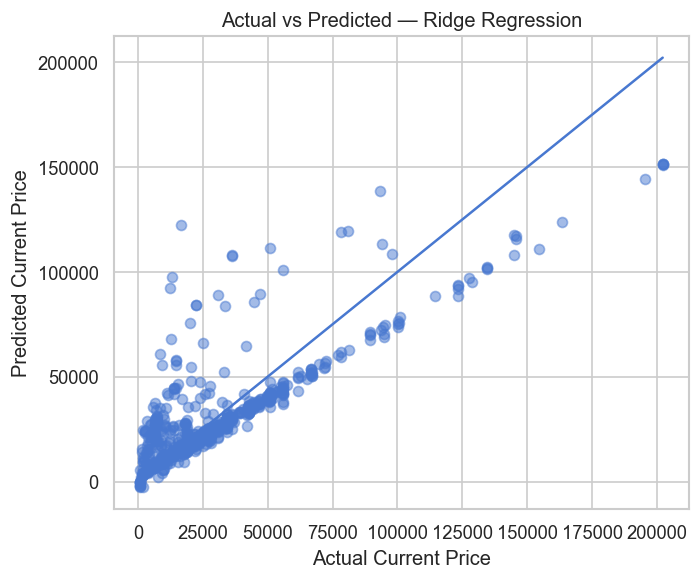

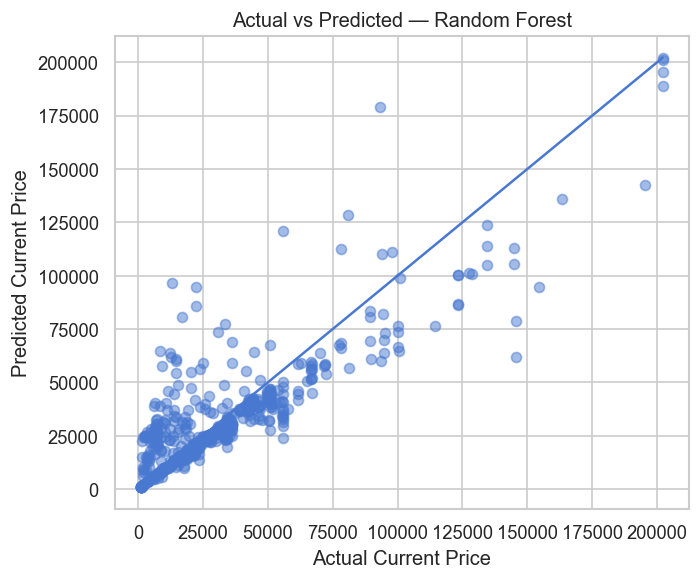

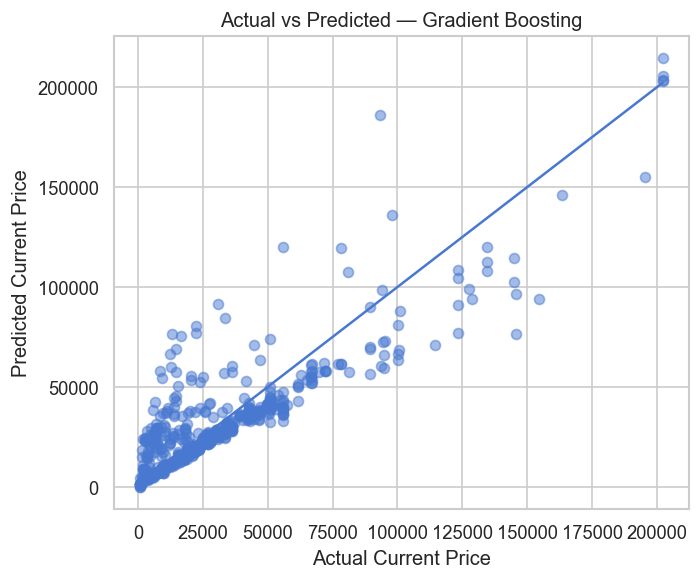

In [33]:
# Actual vs Predicted plots for all regression models

predictions = {
    "Linear Regression": y_pred_lin,
    "Ridge Regression": y_pred_ridge,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for model_name, preds in predictions.items():
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test_reg, preds, alpha=0.5)
    plt.plot(
        [y_test_reg.min(), y_test_reg.max()],
        [y_test_reg.min(), y_test_reg.max()]
    )
    plt.xlabel("Actual Current Price")
    plt.ylabel("Predicted Current Price")
    plt.title(f"Actual vs Predicted — {model_name}")
    plt.tight_layout()
    plt.show()

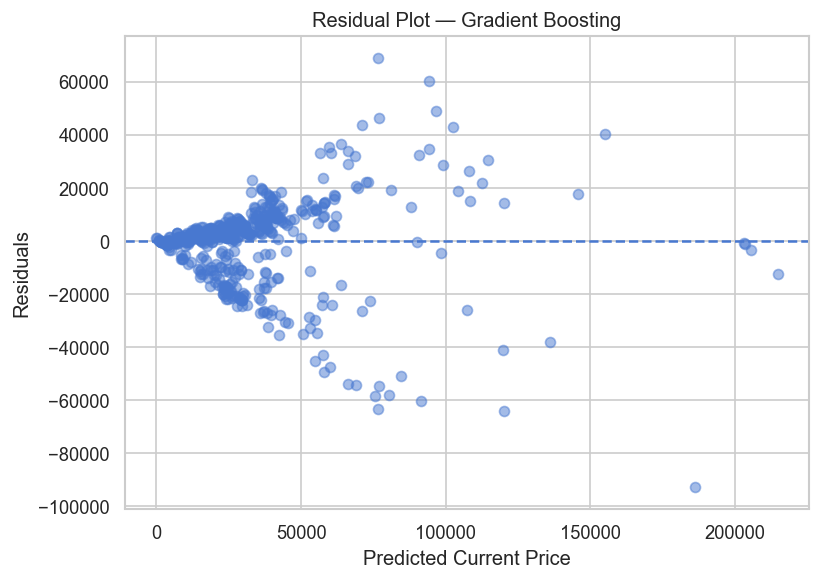

Best regression model based on RMSE: Gradient Boosting


In [34]:
# Residual plot for the best model based on RMSE

best_model_name = regression_results_df.iloc[0]["Model"]
best_predictions = predictions[best_model_name]

residuals = y_test_reg - best_predictions

plt.figure(figsize=(7, 5))
plt.scatter(best_predictions, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Current Price")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.tight_layout()
plt.show()

print("Best regression model based on RMSE:", best_model_name)

In [35]:
# Hyperparameter tuning using 5-fold cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    param_grid=rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train_reg_final, y_train_reg)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV RMSE:")
print(-rf_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV RMSE:
15558.825664376334


,Feature,Importance
1,initial_price,0.836505
0,days_since_release,0.038967
2,review_score,0.031905
4,total_reviews,0.029624
5,achievements_total,0.025648
19,primary_genre_RPG,0.005535
3,log_ownership,0.004067
6,primary_genre_Action,0.003928
20,primary_genre_Racing,0.003645
7,primary_genre_Adventure,0.002944


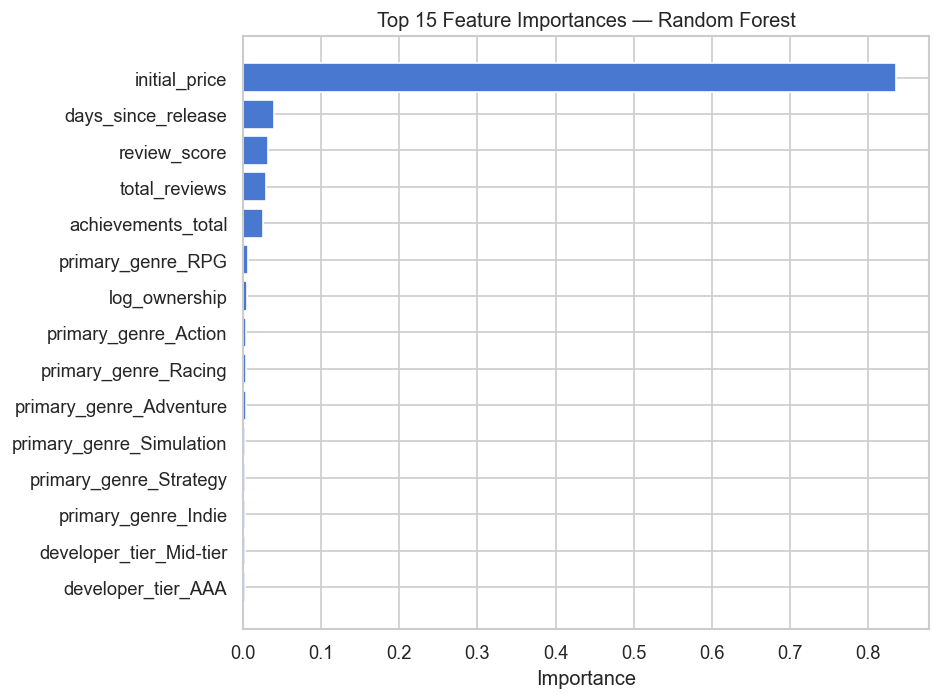

In [36]:
# Feature importance from tuned Random Forest model

best_rf_model = rf_grid.best_estimator_

# Get transformed feature names
ohe = best_rf_model.named_steps['prep'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(cat_features)

feature_names = num_features + list(cat_names)

importances = best_rf_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(15))

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance_df.head(15)["Feature"][::-1],
    feature_importance_df.head(15)["Importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

### Regression Results Summary

Gradient Boosting produced the best regression performance, achieving the lowest RMSE and highest R² among the models tested. This suggests that nonlinear models are better suited for predicting Steam current prices compared to simple linear models.

The actual-versus-predicted plots show that predictions generally follow the diagonal reference line, especially for lower and mid-priced games. However, errors become larger for high-priced games, which is also reflected in the residual plot. This indicates that premium-priced games are harder to predict and may have more irregular pricing behavior.

The feature importance results show that `initial_price` is the strongest predictor of `current_price`, which is expected because a game’s current price is closely tied to its launch price. Other factors such as `days_since_release`, `review_score`, `total_reviews`, and `achievements_total` also contribute, but to a much smaller degree.

> ## Step 4.5: Classification Model — Predict Value Retention Tier

In this step, we build classification models to predict a game's **value_retention_tier**, which categorizes how well a game maintains its price over time.

### Objectives:
- Train baseline and advanced classification models
- Handle class imbalance
- Evaluate using classification metrics
- Analyze model performance and interpretability

### Models Used:
- Logistic Regression (baseline)
- Random Forest Classifier
- Gradient Boosting Classifier

### Evaluation Metrics:
- Accuracy
- Precision, Recall, F1-score (per class)
- Confusion Matrix
- ROC-AUC (one-vs-rest)

Class imbalance is handled using **class_weight='balanced'**.

=== Logistic Regression ===
Accuracy: 0.35209424083769636
                       precision    recall  f1-score   support

       Heavy Discount       0.23      0.53      0.32        66
    Permanent Bargain       0.12      0.25      0.16        83
         Premium Hold       0.23      0.59      0.33        86
Standard Depreciation       0.74      0.31      0.43       529

             accuracy                           0.35       764
            macro avg       0.33      0.42      0.31       764
         weighted avg       0.57      0.35      0.38       764



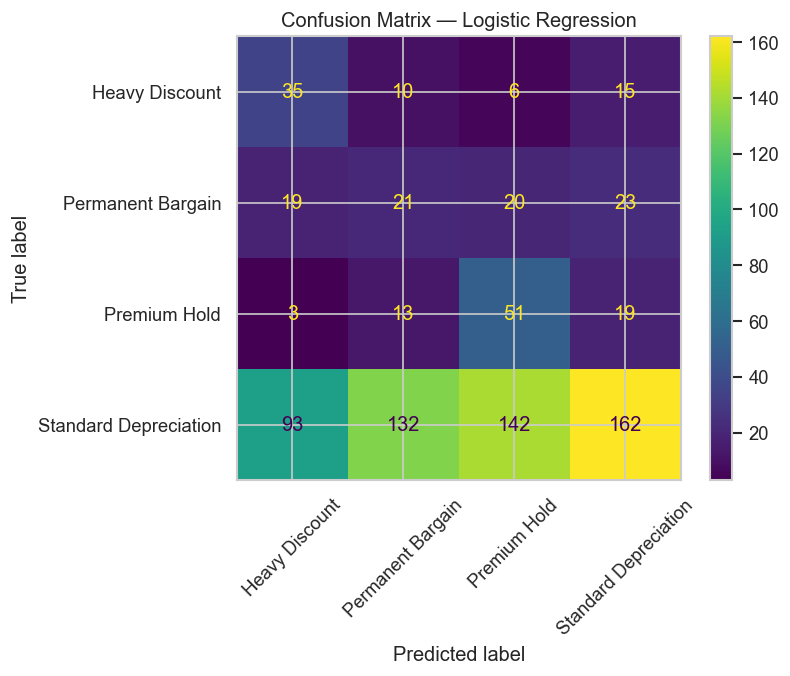

=== Random Forest ===
Accuracy: 0.5850785340314136
                       precision    recall  f1-score   support

       Heavy Discount       0.38      0.38      0.38        66
    Permanent Bargain       0.26      0.33      0.29        83
         Premium Hold       0.27      0.34      0.30        86
Standard Depreciation       0.75      0.69      0.72       529

             accuracy                           0.59       764
            macro avg       0.42      0.43      0.42       764
         weighted avg       0.61      0.59      0.60       764



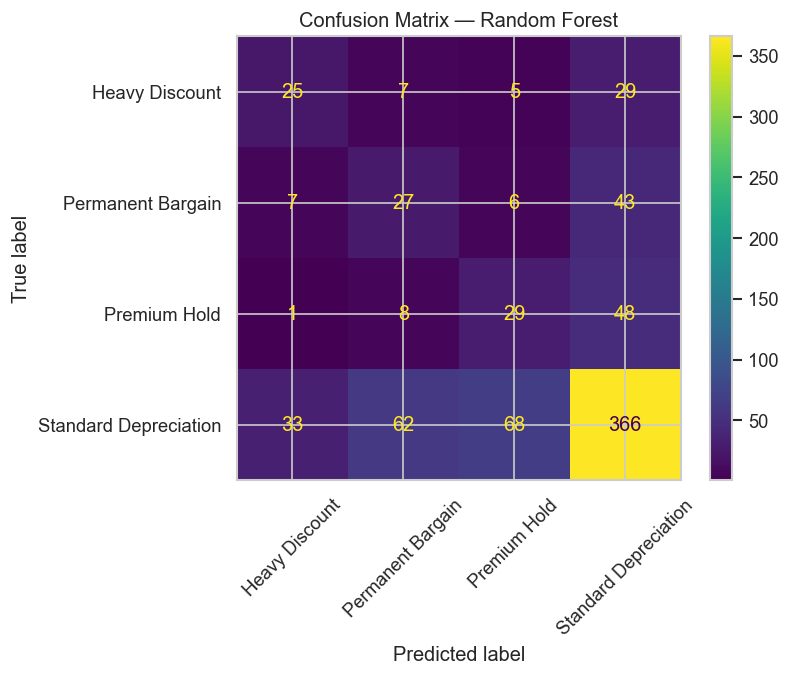

=== Gradient Boosting ===
Accuracy: 0.7198952879581152
                       precision    recall  f1-score   support

       Heavy Discount       0.68      0.23      0.34        66
    Permanent Bargain       0.50      0.08      0.14        83
         Premium Hold       0.71      0.14      0.23        86
Standard Depreciation       0.73      0.98      0.83       529

             accuracy                           0.72       764
            macro avg       0.65      0.36      0.39       764
         weighted avg       0.70      0.72      0.65       764



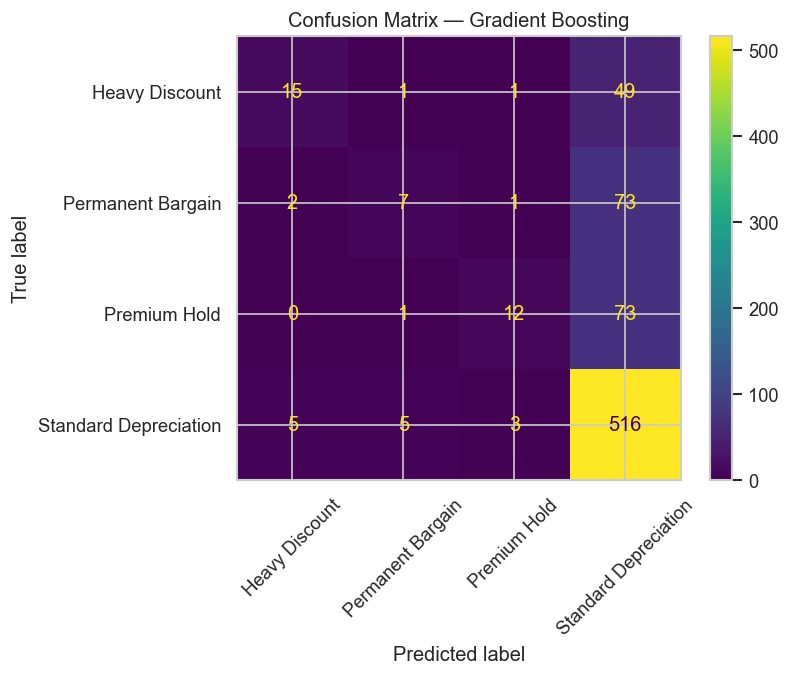

Logistic ROC-AUC: 0.6600613674648663
Random Forest ROC-AUC: 0.7149055806004103
Gradient Boosting ROC-AUC: 0.7247076820097064


<Figure size 960x720 with 0 Axes>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Encode target
le = LabelEncoder()
y_train_cls_enc = le.fit_transform(y_train_cls)
y_test_cls_enc = le.transform(y_test_cls)

# 1. Logistic Regression (Baseline)
log_clf = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_clf.fit(X_train_cls[num_features + cat_features], y_train_cls_enc)
y_pred_log = log_clf.predict(X_test_cls[num_features + cat_features])

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test_cls_enc, y_pred_log))
print(classification_report(y_test_cls_enc, y_pred_log, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls_enc, y_pred_log,
    display_labels=le.classes_,
    xticks_rotation=45
)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

# 2. Random Forest
rf_clf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ))
])

rf_clf.fit(X_train_cls[num_features + cat_features], y_train_cls_enc)
y_pred_rf = rf_clf.predict(X_test_cls[num_features + cat_features])

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test_cls_enc, y_pred_rf))
print(classification_report(y_test_cls_enc, y_pred_rf, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls_enc, y_pred_rf,
    display_labels=le.classes_,
    xticks_rotation=45
)
plt.title("Confusion Matrix — Random Forest")
plt.show()

# 3. Gradient Boosting
gb_clf = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_clf.fit(X_train_cls[num_features + cat_features], y_train_cls_enc)
y_pred_gb = gb_clf.predict(X_test_cls[num_features + cat_features])

print("=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test_cls_enc, y_pred_gb))
print(classification_report(y_test_cls_enc, y_pred_gb, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls_enc, y_pred_gb,
    display_labels=le.classes_,
    xticks_rotation=45
)
plt.title("Confusion Matrix — Gradient Boosting")
plt.show()

# ROC-AUC (One-vs-Rest)
y_test_bin = label_binarize(y_test_cls_enc, classes=np.arange(len(le.classes_)))

models = {
    "Logistic": log_clf,
    "Random Forest": rf_clf,
    "Gradient Boosting": gb_clf
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_cls[num_features + cat_features])
    auc = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")
    print(f"{name} ROC-AUC:", auc)


### Classification Results Summary

Gradient Boosting achieved the highest overall accuracy and ROC-AUC, making it the best-performing classification model. However, performance is heavily influenced by class imbalance, as the "Standard Depreciation" class dominates the dataset.

This is evident in the confusion matrix, where Gradient Boosting correctly classifies most instances of the dominant class but struggles to accurately predict minority classes such as "Heavy Discount", "Permanent Bargain", and "Premium Hold".

While accuracy is high, the macro-average F1 score remains relatively low, indicating that the model does not perform equally well across all classes. This highlights the limitations of accuracy as a metric in imbalanced classification problems.

Random Forest provides a more balanced performance across classes but at the cost of lower overall accuracy. Logistic Regression performs the weakest, as it is unable to capture nonlinear relationships in the data.

Overall, Gradient Boosting is selected as the best model, but further improvements could be achieved by applying techniques such as SMOTE or more advanced class balancing methods.